# Preparación del entorno

In [ ]:
!pip install segmentation-models-pytorch albumentations opencv-python-headless -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 5.0 MB/s eta 0:00:00


In [ ]:
import torch
import os
import cv2
import json
import time
import zipfile
import random
import pandas as pd
import seaborn as sns
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
import albumentations as A
import segmentation_models_pytorch as smp
import requests

from PIL import Image
from io import BytesIO
from tqdm.auto import tqdm
from albumentations.pytorch import ToTensorV2
from torch.utils.data import DataLoader, Dataset, random_split
from google.colab import drive
from datasets import load_dataset

# Descarga del Dataset

In [ ]:
drive.mount('/content/drive')

base_path = f"/content/drive/MyDrive/Master Deep Learning/Modulo 2/Deep Learning para Visión/Final/data"
os.makedirs(base_path, exist_ok=True)

dataset = load_dataset("EduardoPacheco/FoodSeg103")

def guardar_en_drive(split_name, folder_dest):
    img_dir = os.path.join(base_path, folder_dest, "images")
    mask_dir = os.path.join(base_path, folder_dest, "masks")
    os.makedirs(img_dir, exist_ok=True)
    os.makedirs(mask_dir, exist_ok=True)

    print(f"Guardando {split_name} en {folder_dest}")


    for i, example in enumerate(dataset[split_name]):
        img_name = f"food_{i:05d}.jpg"
        example['image'].save(os.path.join(img_dir, img_name))

        mask_name = f"food_{i:05d}.png"
        example['label'].save(os.path.join(mask_dir, mask_name))


guardar_en_drive('train', 'train')
guardar_en_drive('validation', 'val')

Mounted at /content/drive


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00003.parquet:   0%|          | 0.00/351M [00:00<?, ?B/s]

data/train-00001-of-00003.parquet:   0%|          | 0.00/357M [00:00<?, ?B/s]

data/train-00002-of-00003.parquet:   0%|          | 0.00/431M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/115M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/4983 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2135 [00:00<?, ? examples/s]

Guardando train en train
Guardando validation en val


## Visualizar una imangen del Dataset

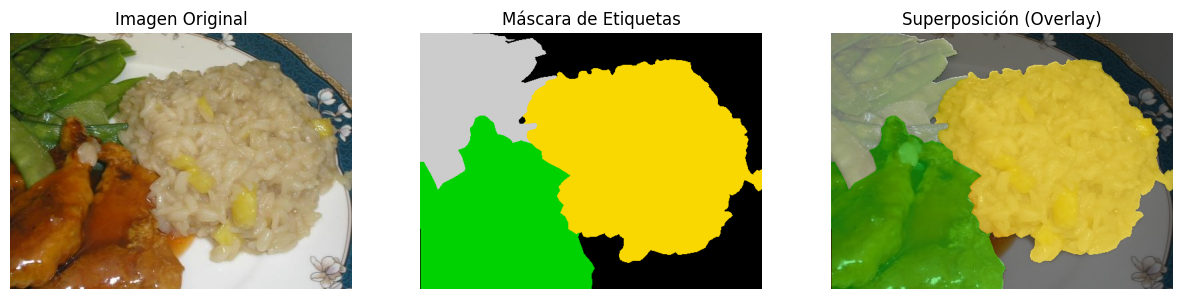

Valores únicos en la máscara (Clases detectadas): [ 0 48 66 90]


In [ ]:
BASE_PATH = f"/content/drive/MyDrive/Master Deep Learning/Modulo 2/Deep Learning para Visión/Final/data/train"
img_folder = os.path.join(BASE_PATH, "images")
mask_folder = os.path.join(BASE_PATH, "masks")

sample_name = os.listdir(img_folder)[0]
img = cv2.imread(os.path.join(img_folder, sample_name))
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
mask = cv2.imread(os.path.join(mask_folder, sample_name.replace(".jpg", ".png")), cv2.IMREAD_GRAYSCALE)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img)
plt.title("Imagen Original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(mask, cmap='nipy_spectral')
plt.title("Máscara de Etiquetas")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(img)
plt.imshow(mask, alpha=0.5, cmap='nipy_spectral')
plt.title("Superposición (Overlay)")
plt.axis("off")

plt.show()

print(f"Valores únicos en la máscara (Clases detectadas): {np.unique(mask)}")

# Exploración de Datos


## Diccionario con los ingredientes

In [ ]:
FOOD_LABELS = {
    0: "background", 1: "candy", 2: "egg tart", 3: "french fries", 4: "chocolate",
    5: "biscuit", 6: "popcorn", 7: "pudding", 8: "ice cream", 9: "cheese butter",
    10: "cake", 11: "wine", 12: "milkshake", 13: "coffee", 14: "juice",
    15: "milk", 16: "tea", 17: "almond", 18: "red beans", 19: "cashew",
    20: "dried cranberries", 21: "soy", 22: "walnut", 23: "peanut", 24: "egg",
    25: "apple", 26: "date", 27: "apricot", 28: "avocado", 29: "banana",
    30: "strawberry", 31: "cherry", 32: "blueberry", 33: "raspberry", 34: "mango",
    35: "olives", 36: "peach", 37: "lemon", 38: "pear", 39: "fig",
    40: "pineapple", 41: "grape", 42: "kiwi", 43: "melon", 44: "orange",
    45: "watermelon", 46: "steak", 47: "pork", 48: "chicken duck", 49: "sausage",
    50: "fried meat", 51: "lamb", 52: "sauce", 53: "crab", 54: "fish",
    55: "shellfish", 56: "shrimp", 57: "soup", 58: "bread", 59: "corn",
    60: "hamburg", 61: "pizza", 62: "hanamaki baozi", 63: "wonton dumplings", 64: "pasta",
    65: "noodles", 66: "rice", 67: "pie", 68: "tofu", 69: "eggplant",
    70: "potato", 71: "garlic", 72: "cauliflower", 73: "tomato", 74: "kelp",
    75: "seaweed", 76: "spring onion", 77: "rape", 78: "ginger", 79: "okra",
    80: "lettuce", 81: "pumpkin", 82: "cucumber", 83: "white radish", 84: "carrot",
    85: "asparagus", 86: "bamboo shoots", 87: "broccoli", 88: "celery stick", 89: "cilantro mint",
    90: "snow peas", 91: "cabbage", 92: "bean sprouts", 93: "onion", 94: "pepper",
    95: "green beans", 96: "French beans", 97: "king oyster mushroom", 98: "shiitake", 99: "enoki mushroom",
    100: "oyster mushroom", 101: "white button mushroom", 102: "salad", 103: "other ingredients"}

## Tamaño del dataset

In [ ]:
def tamano(train_dir, val_dir):
    train_imgs = len(os.listdir(train_dir))
    val_imgs = len(os.listdir(val_dir))
    total = train_imgs + val_imgs

    print(f"Set de Entrenamiento: {train_imgs} imágenes")
    print(f"Set de Validación:    {val_imgs} imágenes")
    print(f"Total de imágenes:    {total}")
    print(f"Proporción: {round(train_imgs/total*100)}% Train / {round(val_imgs/total*100)}% Val")

tamano(img_folder,"/content/drive/MyDrive/Master Deep Learning/Modulo 2/Deep Learning para Visión/Final/data/val/images")

Set de Entrenamiento: 4983 imágenes
Set de Validación:    2135 imágenes
Total de imágenes:    7118
Proporción: 70% Train / 30% Val


## Grafica del top 10 de ingredientes

/tmp/ipykernel_844/1124283351.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10, x='Num_Pixeles', y='Ingrediente', palette='viridis')


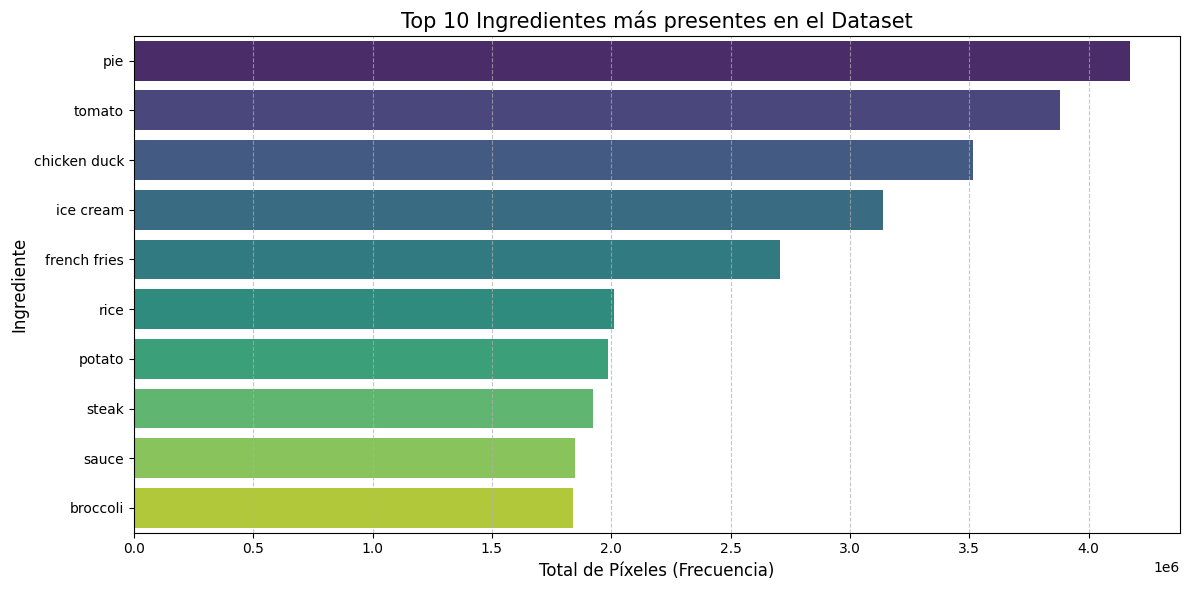

In [ ]:
def eda(mask_dir, labels_dict):
    pixel_counts = {}

    mask_files = [f for f in os.listdir(mask_dir) if f.endswith('.png')][:100]

    for f in mask_files:
        mask_path = os.path.join(mask_dir, f)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        if mask is None: continue

        uniques, counts = np.unique(mask, return_counts=True)
        for u, c in zip(uniques, counts):
            pixel_counts[u] = pixel_counts.get(u, 0) + c

    df = pd.DataFrame(list(pixel_counts.items()), columns=['Clase_ID', 'Num_Pixeles'])

    df['Ingrediente'] = df['Clase_ID'].map(labels_dict)

    top_10 = df[df['Clase_ID'] != 0].sort_values(by='Num_Pixeles', ascending=False).head(10)

    plt.figure(figsize=(12, 6))
    sns.barplot(data=top_10, x='Num_Pixeles', y='Ingrediente', palette='viridis')

    plt.title("Top 10 Ingredientes más presentes en el Dataset", fontsize=15)
    plt.xlabel("Total de Píxeles (Frecuencia)", fontsize=12)
    plt.ylabel("Ingrediente", fontsize=12)
    plt.grid(axis='x', linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

    return df

stats = eda("/content/drive/MyDrive/Master Deep Learning/Modulo 2/Deep Learning para Visión/Final/data/train/masks", FOOD_LABELS)


## Imagen del top 3 de ingredientes

PIE (67)


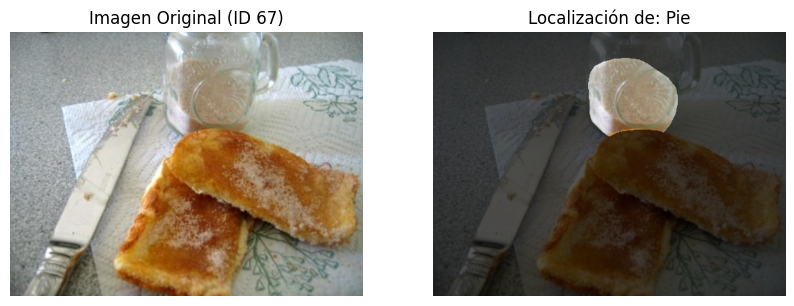

TOMATO (73)


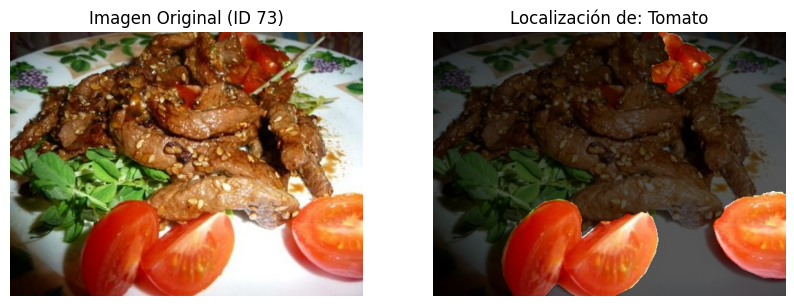

CHICKEN/DUCK (48)


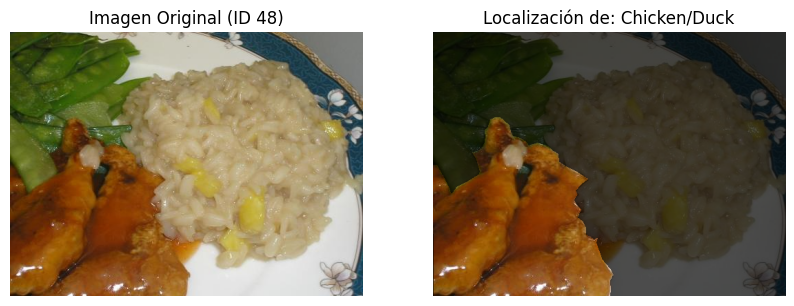

In [ ]:
def visualizar_ingrediente_especifico(target_id, target_name, num_ejemplos=1):
    count = 0

    mask_files = os.listdir(mask_folder)

    for f in mask_files:
        mask_path = os.path.join(mask_folder, f)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        if target_id in np.unique(mask):
            img_path = os.path.join(img_folder, f.replace(".png", ".jpg"))
            image = cv2.imread(img_path)
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

            binary_mask = np.where(mask == target_id, 255, 0).astype('uint8')

            resaltado = image.copy()
            resaltado[mask != target_id] = resaltado[mask != target_id] //

            plt.figure(figsize=(10, 5))
            plt.subplot(1, 2, 1)
            plt.imshow(image)
            plt.title(f"Imagen Original (ID {target_id})")
            plt.axis("off")

            plt.subplot(1, 2, 2)
            plt.imshow(resaltado)
            plt.title(f"Localización de: {target_name}")
            plt.axis("off")
            plt.show()

            count += 1
            if count >= num_ejemplos:
                break

print("PIE (67)")
visualizar_ingrediente_especifico(67, "Pie")

print("TOMATO (73)")
visualizar_ingrediente_especifico(73, "Tomato")

print("CHICKEN/DUCK (48)")
visualizar_ingrediente_especifico(48, "Chicken/Duck")

## Ejemplos aleatorios de PIE

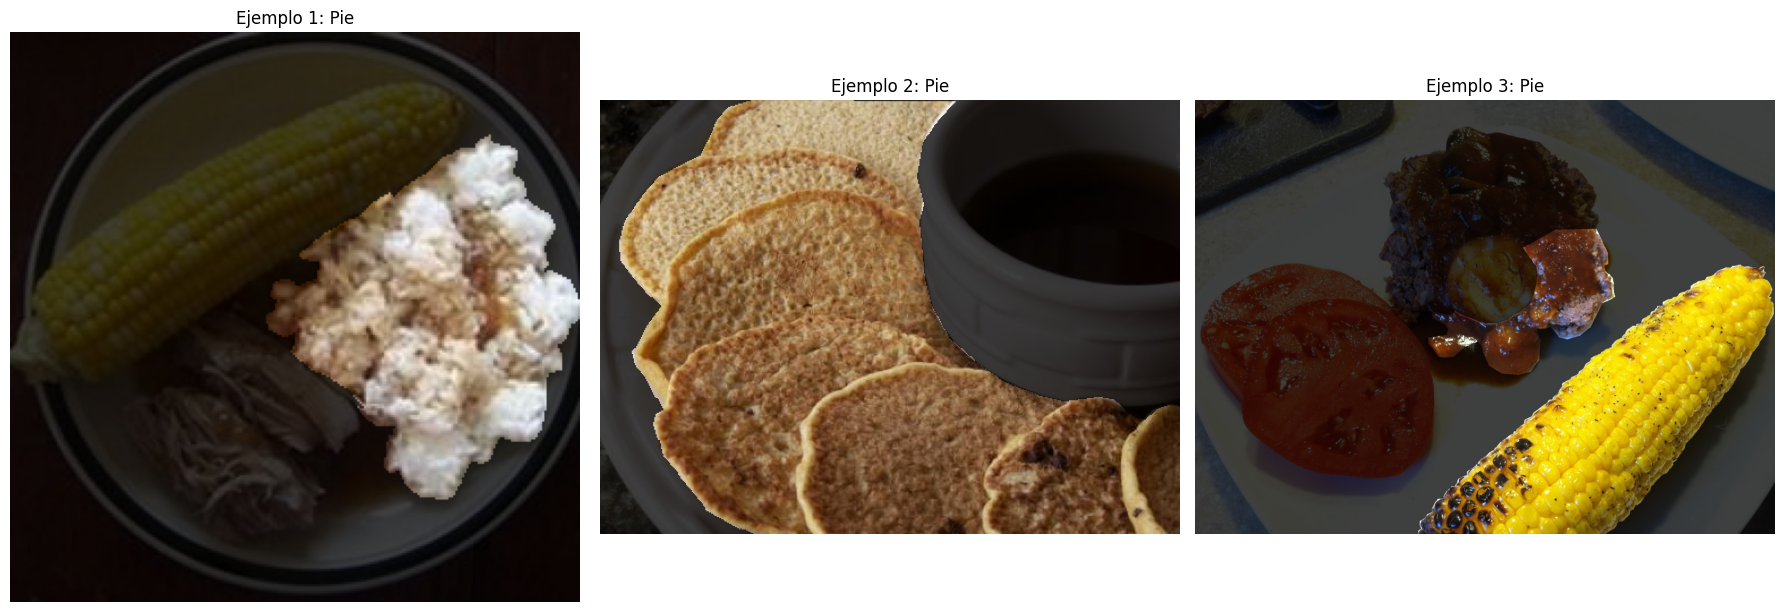

In [ ]:
def ver_varios_ejemplos(target_id, target_name, cantidad=3):
    mask_files = [f for f in os.listdir(mask_folder) if f.endswith('.png')]
    random.shuffle(mask_files)

    encontrados = 0
    plt.figure(figsize=(18, 6))

    for f in mask_files:
        mask_path = os.path.join(mask_folder, f)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        if target_id in np.unique(mask):
            img_path = os.path.join(img_folder, f.replace(".png", ".jpg"))
            image = cv2.imread(img_path)
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

            encontrados += 1
            plt.subplot(1, cantidad, encontrados)

            resaltado = image.copy()
            resaltado[mask != target_id] = resaltado[mask != target_id] // 4

            plt.imshow(resaltado)
            plt.title(f"Ejemplo {encontrados}: {target_name}")
            plt.axis("off")

            if encontrados >= cantidad:
                break

    plt.tight_layout()
    plt.show()

ver_varios_ejemplos(67, "Pie", cantidad=3)

## Analisis de la complejidad del Plato

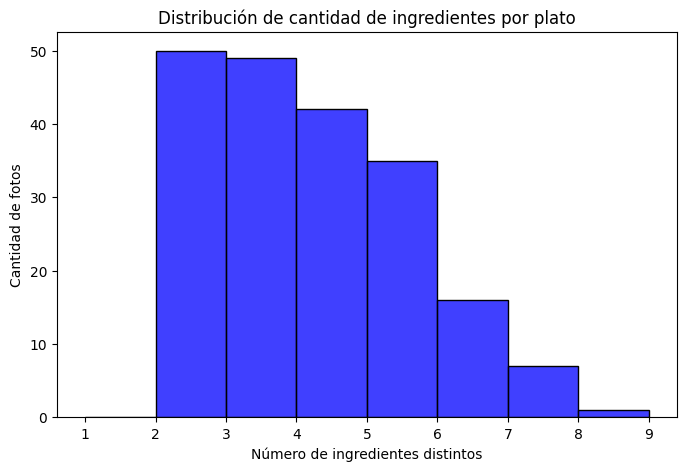

In [ ]:
def analizar_complejidad(mask_dir):
    num_ingredientes_por_foto = []
    mask_files = os.listdir(mask_dir)[:200]

    for f in mask_files:
        mask = cv2.imread(os.path.join(mask_dir, f), cv2.IMREAD_GRAYSCALE)
        n_clases = len(np.unique(mask)) - 1
        num_ingredientes_por_foto.append(n_clases)

    plt.figure(figsize=(8, 5))
    sns.histplot(num_ingredientes_por_foto, bins=range(1, 10), kde=False, color='blue')
    plt.title("Distribución de cantidad de ingredientes por plato")
    plt.xlabel("Número de ingredientes distintos")
    plt.ylabel("Cantidad de fotos")
    plt.show()

analizar_complejidad(mask_folder)

## Grafica de distribución del brillo

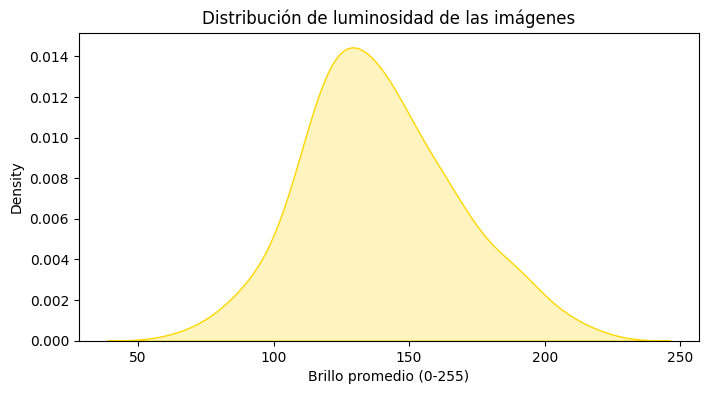

In [ ]:
def analizar_brillo(img_dir):
    brillos = []
    for f in os.listdir(img_dir)[:100]:
        img = cv2.imread(os.path.join(img_dir, f))

        l_channel = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)[:,:,0]
        brillos.append(np.mean(l_channel))

    plt.figure(figsize=(8, 4))
    sns.kdeplot(brillos, fill=True, color="gold")
    plt.title("Distribución de luminosidad de las imágenes")
    plt.xlabel("Brillo promedio (0-255)")
    plt.show()

analizar_brillo(img_folder)

# Dataloaders

In [ ]:
BASE_PATH = "/content/drive/MyDrive/Master Deep Learning/Modulo 2/Deep Learning para Visión/Final/data"
TRAIN_IMG_DIR = os.path.join(BASE_PATH, "train/images")
TRAIN_MASK_DIR = os.path.join(BASE_PATH, "train/masks")
VAL_IMG_DIR = "/content/drive/MyDrive/Master Deep Learning/Modulo 2/Deep Learning para Visión/Final/data/val/images"
VAL_MASK_DIR = "/content/drive/MyDrive/Master Deep Learning/Modulo 2/Deep Learning para Visión/Final/data/val/masks"


In [ ]:
class FoodDataset(Dataset):
    def __init__(self, img_dir, mask_dir, transforms=None):
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.img_names = sorted([f for f in os.listdir(img_dir) if f.endswith('.jpg')])
        self.transforms = transforms

    def __len__(self):
        return len(self.img_names)

    def __getitem__(self, idx):
        img_name = self.img_names[idx]
        mask_name = img_name.replace(".jpg", ".png")

        image = cv2.imread(os.path.join(self.img_dir, img_name))
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(os.path.join(self.mask_dir, mask_name), cv2.IMREAD_GRAYSCALE)

        if self.transforms:
            augmented = self.transforms(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask']

        return image, mask.long()


In [ ]:
transform_base = A.Compose([
    A.Resize(512, 512),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

train_dataset = FoodDataset(TRAIN_IMG_DIR, TRAIN_MASK_DIR)
val_dataset_full = FoodDataset(VAL_IMG_DIR, VAL_MASK_DIR, transforms=transform_base)

val_size = len(val_dataset_full) // 2
test_size = len(val_dataset_full) - val_size
val_subset, test_subset = random_split(
    val_dataset_full, [val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

val_loader = DataLoader(val_subset, batch_size=8, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_subset, batch_size=8, shuffle=False, num_workers=2, pin_memory=True)


print(f"{len(train_dataset)} Train | {len(val_subset)} Val | {len(test_subset)} Test")

4983 Train | 1067 Val | 1068 Test


# Modelo

## Baseline

### Transformer simple

In [ ]:
train_dataset.transforms = transform_base
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=0, pin_memory=True)

### Configuración del Modelo y Optimización

In [ ]:
model = smp.DeepLabV3Plus(
    encoder_name="resnet50",
    encoder_weights="imagenet",
    in_channels=3,
    classes=104
).cuda()

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)
device = "cuda"

config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

### Bucle de Entrenamiento

In [ ]:
def entrenamiento(model, train_loader, val_loader, epochs=5):
    history = {'train_loss': [], 'val_loss': []}
    best_val_loss = float('inf')


    CHECKPOINT_PATH = os.path.join(BASE_PATH, "checkpoint_baseline.pth")
    HISTORY_PATH = os.path.join(BASE_PATH, "history_baseline.json")

    for epoch in range(epochs):
        model.train()
        t_loss = 0

        pbar_train = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]")

        for imgs, masks in pbar_train:
            imgs, masks = imgs.to(device), masks.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, masks)
            loss.backward()
            optimizer.step()

            t_loss += loss.item()
            pbar_train.set_postfix(loss=f"{loss.item():.4f}")

        avg_train_loss = t_loss / len(train_loader)

        model.eval()
        v_loss = 0
        pbar_val = tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} [Val]")

        with torch.no_grad():
            for imgs, masks in pbar_val:
                imgs, masks = imgs.to(device), masks.to(device)
                loss_v = criterion(model(imgs), masks)
                v_loss += loss_v.item()
                pbar_val.set_postfix(loss=f"{loss_v.item():.4f}")

        avg_val_loss = v_loss / len(val_loader)

        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save(model.state_dict(), CHECKPOINT_PATH)


        with open(HISTORY_PATH, 'w') as f:
            json.dump(history, f)

        print(f"Epoch {epoch+1}: Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

    return history

history_a = entrenamiento(model, train_loader, val_loader, epochs=5)

Epoch 1/5 [Train]:   0%|          | 0/623 [00:00<?, ?it/s]

Epoch 1/5 [Val]:   0%|          | 0/134 [00:00<?, ?it/s]

Epoch 1: Train Loss: 1.9895 | Val Loss: 1.3642


Epoch 2/5 [Train]:   0%|          | 0/623 [00:00<?, ?it/s]

Epoch 2/5 [Val]:   0%|          | 0/134 [00:00<?, ?it/s]

...

Epoch 4/5 [Val]:   0%|          | 0/134 [00:00<?, ?it/s]

Epoch 4: Train Loss: 0.9729 | Val Loss: 1.0599


Epoch 5/5 [Train]:   0%|          | 0/623 [00:00<?, ?it/s]

Epoch 5/5 [Val]:   0%|          | 0/134 [00:00<?, ?it/s]

Epoch 5: Train Loss: 0.8433 | Val Loss: 1.0540


### Graficas de entrenamiento

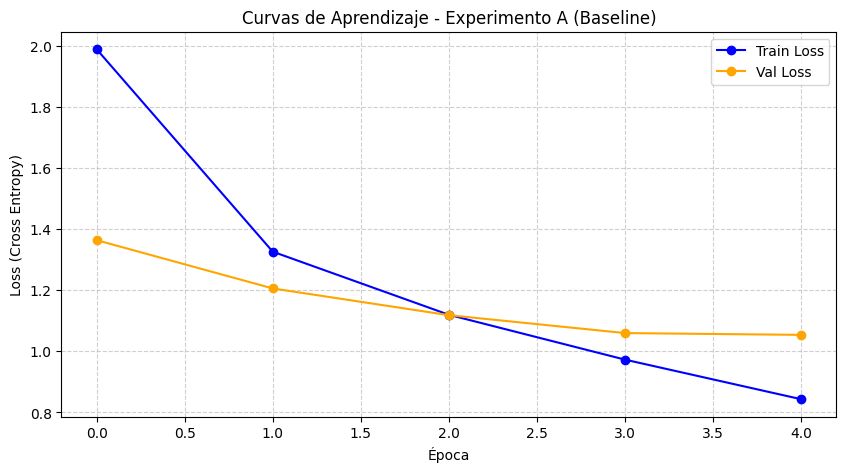

In [ ]:
def graficar_curvas(history):
    plt.figure(figsize=(10, 5))
    plt.plot(history['train_loss'], label='Train Loss', color='blue', marker='o')
    plt.plot(history['val_loss'], label='Val Loss', color='orange', marker='o')
    plt.title('Curvas de Aprendizaje - Experimento A (Baseline)')
    plt.xlabel('Época')
    plt.ylabel('Loss (Cross Entropy)')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

graficar_curvas(history_a)

### Evaluacion en Test

Evaluando:   0%|          | 0/134 [00:00<?, ?it/s]

Mean IoU Final (Test): 0.5801
3 ejemplos de predicción:


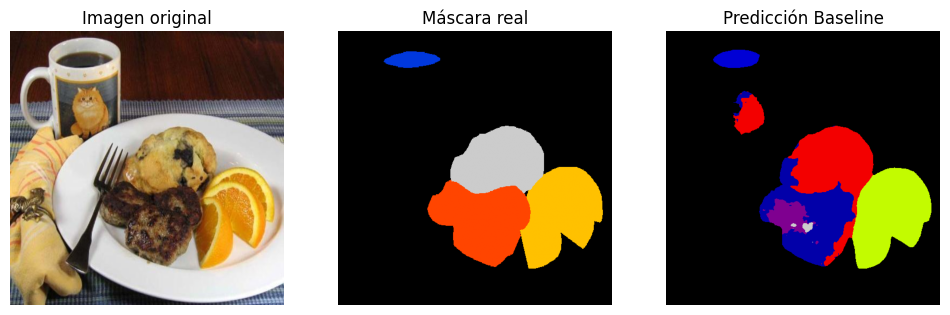

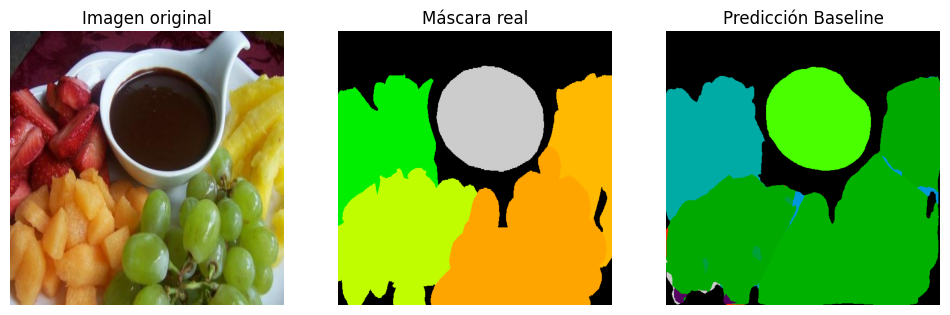

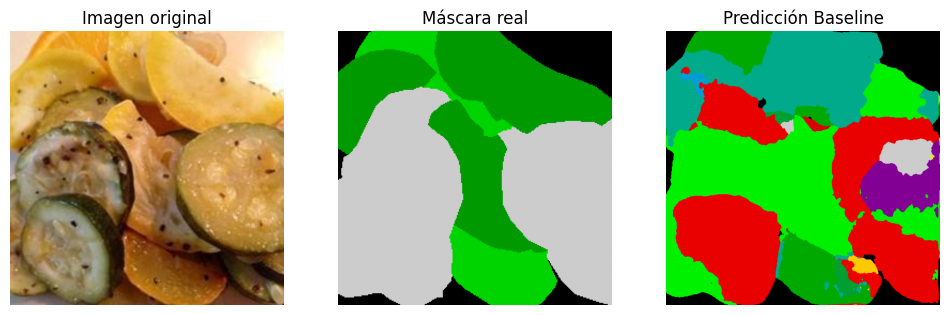

In [ ]:
def evaluar_y_visualizar(model, loader, dataset, device, num_ejemplos=3):
    model.eval()
    total_iou = 0

    with torch.no_grad():
        for imgs, masks in tqdm(loader, desc="Evaluando"):
            imgs, masks = imgs.to(device), masks.to(device)
            outputs = model(imgs)

            tp, fp, fn, tn = smp.metrics.get_stats(
                outputs.argmax(1), masks, mode='multiclass', num_classes=104
            )
            total_iou += smp.metrics.iou_score(tp, fp, fn, tn, reduction="micro")

    print(f"Mean IoU Final (Test): {total_iou/len(loader):.4f}")

    print(f"{num_ejemplos} ejemplos de predicción:")
    indices = [10, 50, 100]

    for idx in indices:
        image, mask = dataset[idx]
        input_img = image.unsqueeze(0).to(device)

        with torch.no_grad():
            pred = model(input_img).argmax(1).cpu().numpy()[0]

        plt.figure(figsize=(12, 4))
        plt.subplot(1, 3, 1)
        img_show = image.permute(1, 2, 0).cpu().numpy()
        img_show = (img_show * [0.229, 0.224, 0.225]) + [0.485, 0.456, 0.406]
        plt.imshow(img_show.clip(0, 1))
        plt.title("Imagen original")
        plt.axis('off')

        plt.subplot(1, 3, 2)
        plt.imshow(mask.cpu().numpy(), cmap='nipy_spectral')
        plt.title("Máscara real")
        plt.axis('off')

        plt.subplot(1, 3, 3)
        plt.imshow(pred, cmap='nipy_spectral')
        plt.title("Predicción Baseline")
        plt.axis('off')
        plt.show()

evaluar_y_visualizar(model, test_loader, test_subset, device)

## Modelo Optimizado

### Nuevas Transformaciones

In [ ]:
transform_augmented = A.Compose([
    A.Resize(512, 512),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.1),
    A.RandomBrightnessContrast(p=0.3),
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.1, rotate_limit=20, p=0.5),
    A.RGBShift(r_shift_limit=15, g_shift_limit=15, b_shift_limit=15, p=0.3),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

train_dataset.transforms = transform_augmented
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=2, pin_memory=True)

/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


### Loss Híbrido (Dice + CrossEntropy)

In [ ]:
dice_loss_fn = smp.losses.DiceLoss(mode='multiclass')
ce_loss_fn = nn.CrossEntropyLoss()

def criterion_2(y_pred, y_true):
    return 0.5 * dice_loss_fn(y_pred, y_true) + 0.5 * ce_loss_fn(y_pred, y_true)

### Reset del Modelo y Optimizador

In [ ]:
model_2 = smp.DeepLabV3Plus(
    encoder_name="resnet50",
    encoder_weights="imagenet",
    in_channels=3,
    classes=104
).cuda()

optimizer = optim.Adam(model_2.parameters(), lr=0.0001)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=2, factor=0.5)

CHECKPOINT_B = os.path.join(BASE_PATH, "mejor_modelo_B.pth")
HISTORY_B = os.path.join(BASE_PATH, "history_B.json")

### Bucle de entrenamiento

In [ ]:
def entrenamiento_modelo_2(model, train_loader, val_loader, loss_fn, epochs=10):
    history = {'train_loss': [], 'val_loss': []}
    best_val_loss = float('inf')

    CHECKPOINT_B = os.path.join(BASE_PATH, "mejor_modelo_2.pth")
    HISTORY_B = os.path.join(BASE_PATH, "history_2.json")

    for epoch in range(epochs):
        model.train()
        t_loss = 0
        pbar_train = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train 2]")

        for imgs, masks in pbar_train:
            imgs, masks = imgs.to(device), masks.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)

            loss = loss_fn(outputs, masks)

            loss.backward()
            optimizer.step()
            t_loss += loss.item()
            pbar_train.set_postfix(loss=f"{loss.item():.4f}")

        model.eval()
        v_loss = 0
        pbar_val = tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} [Val 2]")
        with torch.no_grad():
            for imgs, masks in pbar_val:
                imgs, masks = imgs.to(device), masks.to(device)
                loss_v = loss_fn(model(imgs), masks)
                v_loss += loss_v.item()

        avg_train_loss = t_loss / len(train_loader)
        avg_val_loss = v_loss / len(val_loader)
        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save(model.state_dict(), CHECKPOINT_B)


        print(f"Epoch {epoch+1} Finalizada")

    return history


history_2 = entrenamiento_modelo_2(
    model_2,
    train_loader,
    val_loader,
    loss_fn=criterion_2,
    epochs=10
)

Epoch 1/10 [Train 2]:   0%|          | 0/623 [00:00<?, ?it/s]

Epoch 1/10 [Val 2]:   0%|          | 0/134 [00:00<?, ?it/s]

Epoch 1 Finalizada


Epoch 2/10 [Train 2]:   0%|          | 0/623 [00:00<?, ?it/s]

Epoch 2/10 [Val 2]:   0%|          | 0/134 [00:00<?, ?it/s]

...

Epoch 9/10 [Val 2]:   0%|          | 0/134 [00:00<?, ?it/s]

Epoch 9 Finalizada


Epoch 10/10 [Train 2]:   0%|          | 0/623 [00:00<?, ?it/s]

Epoch 10/10 [Val 2]:   0%|          | 0/134 [00:00<?, ?it/s]

Epoch 10 Finalizada


### Evaluación en Test

In [ ]:
test_loader_safe = DataLoader(test_subset, batch_size=8, shuffle=False, num_workers=0, pin_memory=True)

def eval_model_final(model, loader, device, nombre_modelo="Modelo 2"):
    model.eval()
    total_iou = 0

    with torch.no_grad():
        for imgs, masks in tqdm(loader, desc="Calculando IoU"):
            imgs, masks = imgs.to(device), masks.to(device)
            outputs = model(imgs)

            tp, fp, fn, tn = smp.metrics.get_stats(
                outputs.argmax(1), masks, mode='multiclass', num_classes=104
            )
            total_iou += smp.metrics.iou_score(tp, fp, fn, tn, reduction="micro")

    avg_iou = total_iou / len(loader)
    print(f"Resultado final {nombre_modelo}:")
    print(f"Mean IoU: {avg_iou:.4f}")
    return avg_iou

iou_modelo_2 = eval_model_final(model_2, test_loader_safe, device)

Calculando IoU:   0%|          | 0/134 [00:00<?, ?it/s]

Resultado final Modelo 2:
Mean IoU: 0.6031


## Grafica comparativa

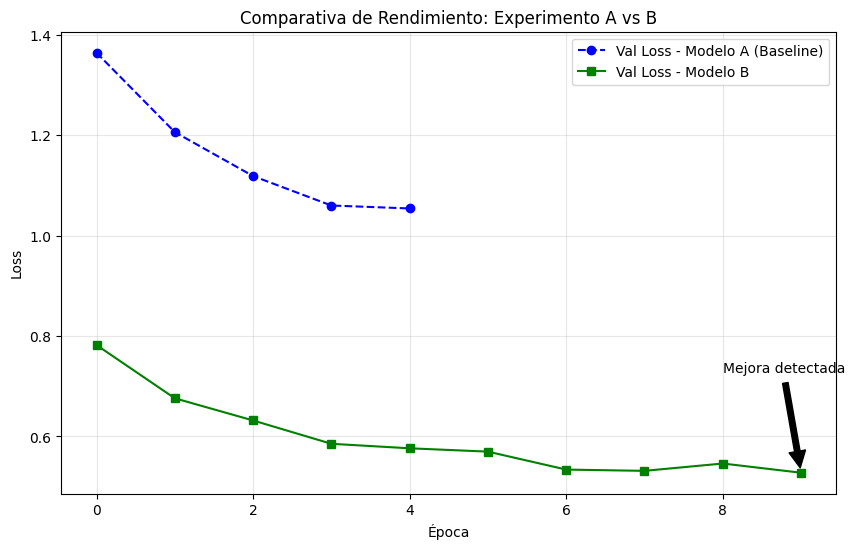

In [ ]:
def grafica_comparativa(h_a, h_b):
    plt.figure(figsize=(10, 6))

    plt.plot(h_a['val_loss'], label='Val Loss - Modelo A (Baseline)', color='blue', linestyle='--', marker='o')
    plt.plot(h_b['val_loss'], label='Val Loss - Modelo B', color='green', marker='s')

    plt.title('Comparativa de Rendimiento: Experimento A vs B')
    plt.xlabel('Época')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)

    if h_b['val_loss'][-1] < h_a['val_loss'][-1]:
        plt.annotate('Mejora detectada', xy=(len(h_b['val_loss'])-1, h_b['val_loss'][-1]),
                     xytext=(len(h_b['val_loss'])-2, h_b['val_loss'][-1]+0.2),
                     arrowprops=dict(facecolor='black', shrink=0.05))

    plt.show()

grafica_comparativa(history_a, history_2)

## Comparación Visual (Detección de Ruido)

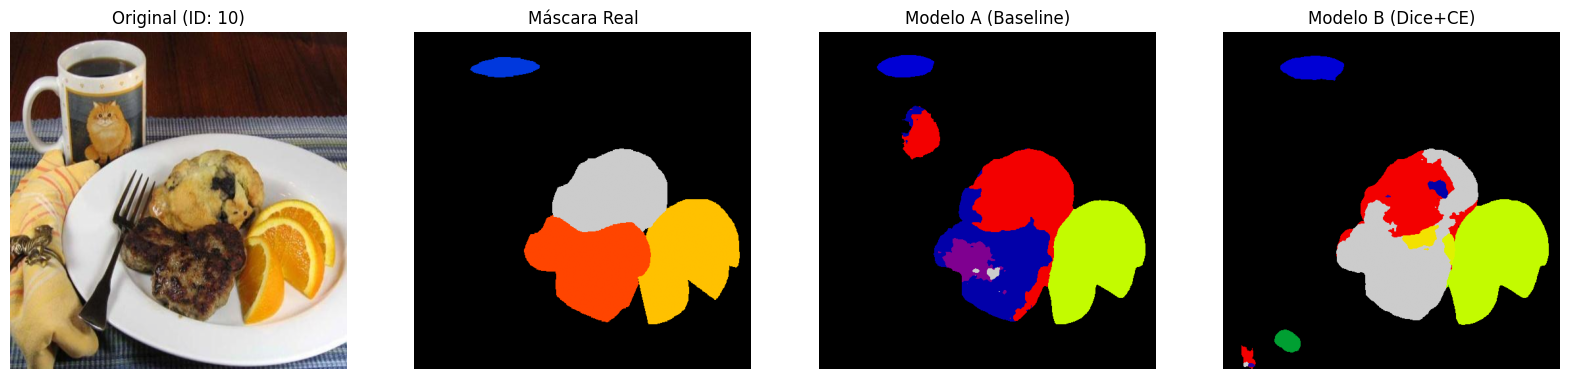

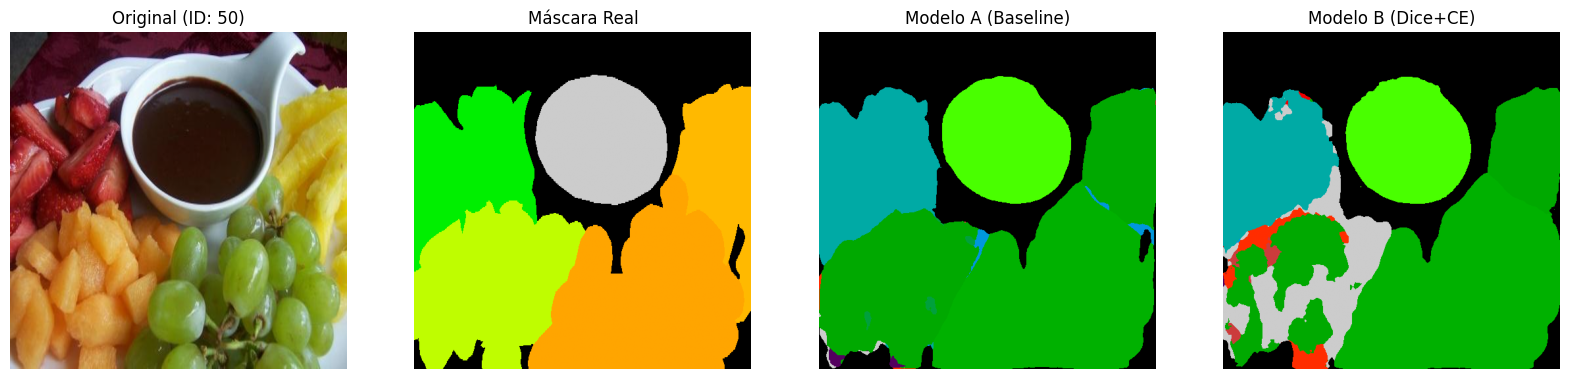

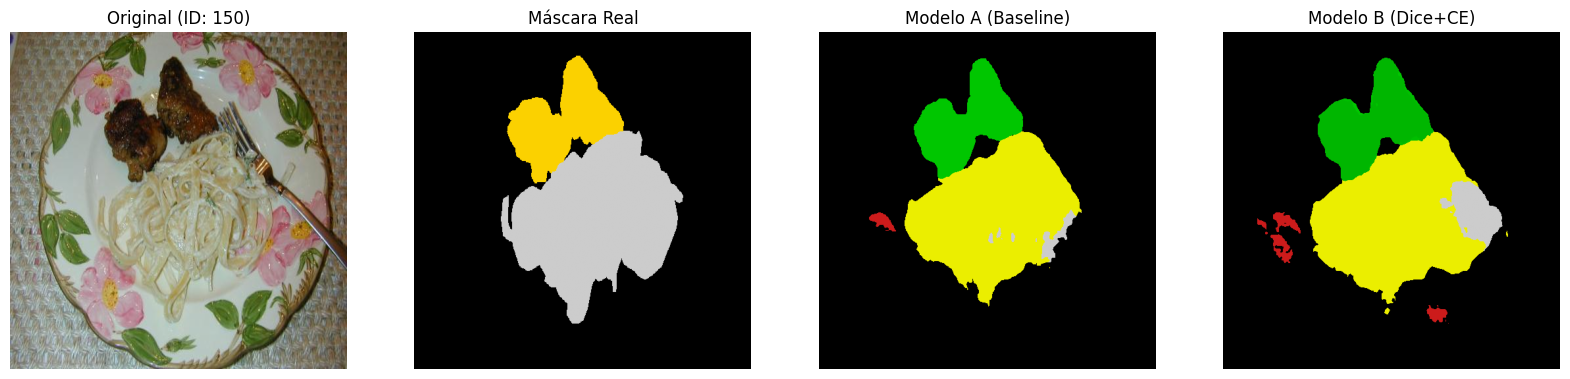

In [ ]:
def comparar_resultados_visuales(idx_lista=[10, 50, 100]):
    model_a = smp.DeepLabV3Plus(encoder_name="resnet50", classes=104).cuda()
    model_a.load_state_dict(torch.load(os.path.join(base_path, "checkpoint_baseline.pth")))
    model_a.eval()

    model_2.eval()

    for idx in idx_lista:
        image, mask = test_subset[idx]
        input_img = image.unsqueeze(0).to(device)

        with torch.no_grad():
            pred_a = model_a(input_img).argmax(1).cpu().numpy()[0]
            pred_b = model_2(input_img).argmax(1).cpu().numpy()[0]

        plt.figure(figsize=(20, 5))

        plt.subplot(1, 4, 1); plt.title(f"Original (ID: {idx})")
        img_raw = image.permute(1,2,0).cpu().numpy()
        img_raw = (img_raw * [0.229, 0.224, 0.225]) + [0.485, 0.456, 0.406]
        plt.imshow(img_raw.clip(0,1)); plt.axis('off')

        plt.subplot(1, 4, 2); plt.title("Máscara Real"); plt.imshow(mask.cpu().numpy(), cmap='nipy_spectral'); plt.axis('off')
        plt.subplot(1, 4, 3); plt.title("Modelo A (Baseline)"); plt.imshow(pred_a, cmap='nipy_spectral'); plt.axis('off')
        plt.subplot(1, 4, 4); plt.title("Modelo B (Dice+CE)"); plt.imshow(pred_b, cmap='nipy_spectral'); plt.axis('off')

        plt.show()

comparar_resultados_visuales(idx_lista=[10, 50, 150])

# Prueba real

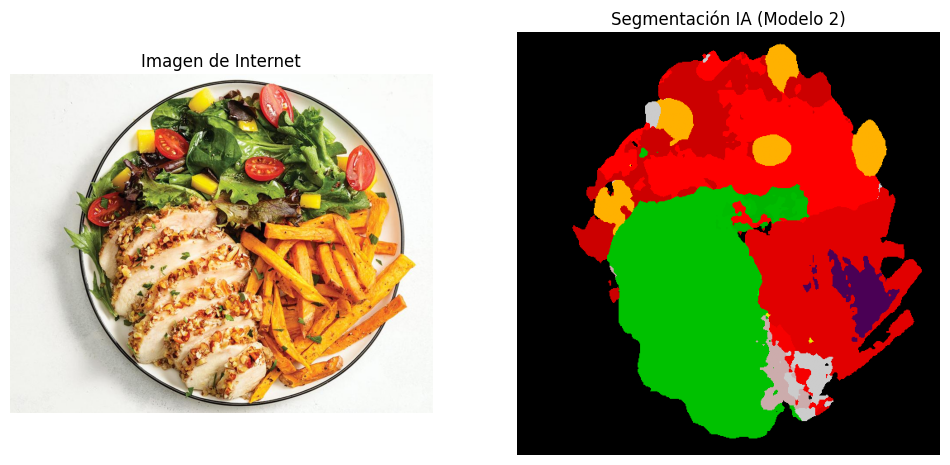

IDs de ingredientes detectados: [ 0  3 46 47 48 54 65 73 80 81 84 89 93 94]


In [ ]:
import requests
from PIL import Image
from io import BytesIO

def segmentar_imagen_internet(url_o_ruta, model, device):
    if url_o_ruta.startswith('http'):
        response = requests.get(url_o_ruta)
        img = Image.open(BytesIO(response.content)).convert('RGB')
    else:
        img = Image.open(url_o_ruta).convert('RGB')

    transform_val = A.Compose([
        A.Resize(512, 512),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2(),
    ])

    img_np = np.array(img)
    augmented = transform_val(image=img_np)
    img_tensor = augmented['image'].unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        output = model(img_tensor)
        pred_mask = output.argmax(1).cpu().numpy()[0]

    plt.figure(figsize=(12, 6))

    plt.subplot(1, 2, 1)
    plt.imshow(img_np)
    plt.title("Imagen de Internet")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(pred_mask, cmap='nipy_spectral')
    plt.title("Segmentación IA (Modelo 2)")
    plt.axis('off')

    plt.show()

    ingredientes_detectados = np.unique(pred_mask)
    print(f"IDs de ingredientes detectados: {ingredientes_detectados}")

URL_PRUEBA = "https://diabetesfoodhub.org/sites/foodhub/files/styles/recipe_hero_banner_720w_2x/public/1837-diabetic-pecan-crusted-chicken-breast_JulAug20DF_clean-simple_061720.jpg?h=48784f2c&itok=A99Z5Tow"

segmentar_imagen_internet(URL_PRUEBA, model_2, device)

In [ ]:
ids_detectados = [0, 3, 46, 47, 48, 54, 65, 73, 80, 81, 84, 89, 93, 94]
print("Ingredientes identificados en la foto:")
for i in ids_detectados:
    if i < len(FOOD_LABELS):
        print(f"ID {i}: {FOOD_LABELS[i]}")

Ingredientes identificados en la foto:
ID 0: background
ID 3: french fries
ID 46: steak
ID 47: pork
ID 48: chicken duck
ID 54: fish
ID 65: noodles
ID 73: tomato
ID 80: lettuce
ID 81: pumpkin
ID 84: carrot
ID 89: cilantro mint
ID 93: onion
ID 94: pepper
